In [1]:
import pandas as pd
# Classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Core libraries
import os
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

# Preprocessing & splitting
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


from sklearn.ensemble import StackingRegressor
import lightgbm as lgb
from sklearn.feature_extraction.text import HashingVectorizer
import warnings
warnings.filterwarnings('ignore')

In [2]:
MODEL_DIR = "models"
RESULTS_DIR = "results"

Path(MODEL_DIR).mkdir(exist_ok=True)
Path(RESULTS_DIR).mkdir(exist_ok=True)


In [3]:
df = pd.read_csv('Dataset/JomaShop Products Data.csv')
df

,product_type,name,brandName,stockStatus,description.short,description.complete,genderLabel,department,pricing.regularPrice.value,pricing.finalPrice.value,pricing.retailPrice.value
0,SimpleProduct,Tissot PRX Powermatic 80 Automatic Blue Dial M...,Tissot,IN_STOCK,Tissot T137.407.11.041.00 Mens,Stainless steel case with a stainless steel br...,Mens,Watches,696.99,534.00,750.0
1,SimpleProduct,Omega Speedmaster Racing Automatic Chronograph...,Omega,IN_STOCK,Omega 326.30.40.50.01.001 Mens,Silver-tone stainless steel case and bracelet....,Mens,Watches,4394.99,3650.00,4800.0
2,SimpleProduct,Breitling Endurance Pro Chronograph Quartz Chr...,Breitling,IN_STOCK,Breitling X82310D31B1S1 Mens,Black breitlight case with a green rubber stra...,Mens,Watches,2879.99,2050.00,3500.0
3,SimpleProduct,Tissot Gentleman Automatic Black Dial Watch T1...,Tissot,IN_STOCK,Tissot T127.407.16.051.01 Mens,Silver-tone stainless steel case with a brown ...,Mens,Watches,564.99,389.00,825.0
4,SimpleProduct,Tissot PRX Quartz Blue Dial Men's Watch T137.4...,Tissot,IN_STOCK,Tissot T137.410.11.041.00 Mens,Stainless steel case with a stainless steel br...,Mens,Watches,336.99,289.00,415.0
...,...,...,...,...,...,...,...,...,...,...,...
93926,SimpleProduct,Smythson 2022 Panama Diary With Pocket In Lapis,Smythson,IN_STOCK,Smythson 1200161 LAPIS Unisex,Smythson Unisex Notebook. SKU: 1200161 LAPIS O...,Unisex,Accessories,65.99,15.00,85.0
93927,SimpleProduct,Montblanc Black Extreme Flip Cover Black Leath...,Montblanc,IN_STOCK,MontBlanc 115100 Unisex,MontBlanc Unisex Phone Case. SKU: 115100. Colo...,Unisex,Accessories,150.99,61.00,210.0
93928,SimpleProduct,Montblanc Soft Grain Samsung Note 4 Case,Montblanc,IN_STOCK,MontBlanc 113387 Unisex,MontBlanc Phone Case. SKU: 113387. Color: Blac...,Unisex,Accessories,202.99,87.00,245.0
93929,GroupedProduct,Dior Jadore L'Or Essence De Parfum Ladies EDP,NaN,OUT_OF_STOCK,NaN,NaN,Unisex,NaN,137.99,109.99,0.0


In [4]:
def preprocess_data(df, is_train=True):
    df = df.copy()

    # ---------------- Text Cleanup ----------------
    df["content"] = (
        df.get("name", "") + " " +
        df.get("description.short", "") + " " +
        df.get("description.complete", "")
    ).astype(str).str.lower()

    # ---------------- Brand Encoding ----------------
    brand_enc_path = os.path.join(MODEL_DIR, "brand_encoder.pkl")
    if is_train:
        brand_le = LabelEncoder()
        df["brand_encoded"] = brand_le.fit_transform(df["brandName"])
        joblib.dump(brand_le, brand_enc_path)
    else:
        brand_le = joblib.load(brand_enc_path)
        df["brand_encoded"] = brand_le.transform(df["brandName"])

    # ---------------- Target Encoding ----------------
    target_enc_path = os.path.join(MODEL_DIR, "product_type_encoder.pkl")
    if "product_type" in df.columns:
        if is_train:
            target_le = LabelEncoder()
            y = target_le.fit_transform(df["product_type"])
            joblib.dump(target_le, target_enc_path)
        else:
            target_le = joblib.load(target_enc_path)
            y = target_le.transform(df["product_type"])
    else:
        y = None  # No labels in this dataset

    # ---------------- Text Vectorization ----------------
    vectorizer = HashingVectorizer(
        n_features=2**18,
        stop_words="english",
        ngram_range=(1, 2),
        alternate_sign=False
    )
    X_text = vectorizer.transform(df["content"])

    # ---------------- Categorical Feature Scaling ----------------
    scaler_path = os.path.join(MODEL_DIR, "cat_scaler.pkl")
    cat_features = df[["brand_encoded"]]

    if is_train:
        scaler = StandardScaler(with_mean=False)
        X_cat = scaler.fit_transform(cat_features)
        joblib.dump(scaler, scaler_path)
    else:
        scaler = joblib.load(scaler_path)
        X_cat = scaler.transform(cat_features)

    # ---------------- Combine Features ----------------
    X = hstack([X_text, X_cat])

    return X, y


In [5]:
X, y = preprocess_data(df)


# EDA

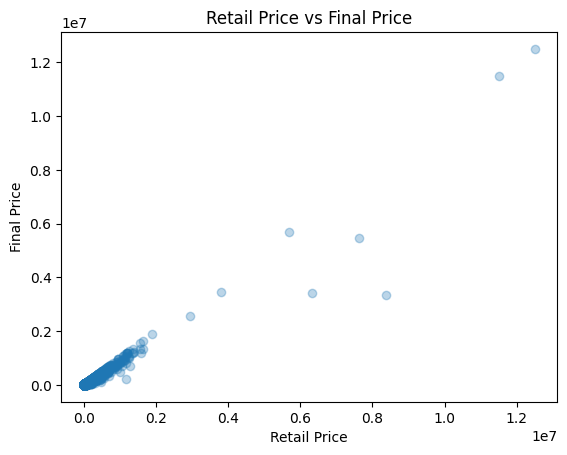

In [6]:
plt.figure()
plt.scatter(
    df["pricing.retailPrice.value"],
    df["pricing.finalPrice.value"],
    alpha=0.3
)
plt.xlabel("Retail Price")
plt.ylabel("Final Price")
plt.title("Retail Price vs Final Price")
plt.show()


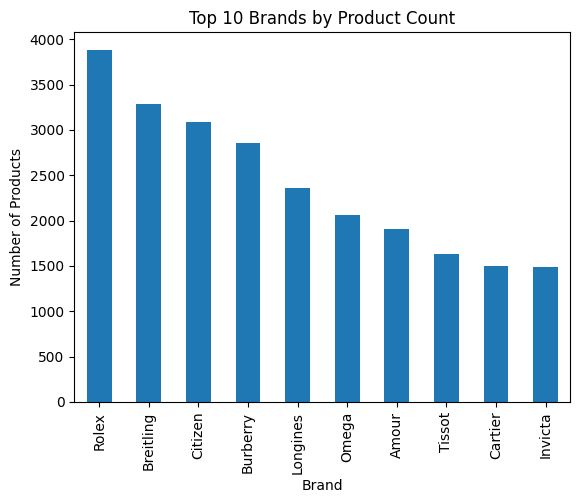

In [7]:
plt.figure()
df["brandName"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.title("Top 10 Brands by Product Count")
plt.show()


<Figure size 640x480 with 0 Axes>

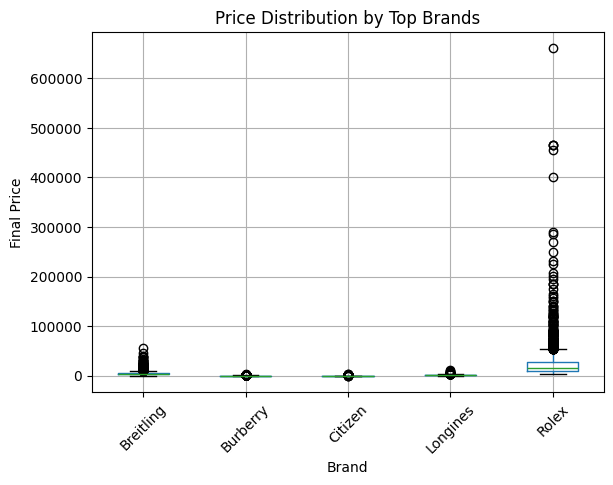

In [8]:
top_brands = df["brandName"].value_counts().head(5).index
subset = df[df["brandName"].isin(top_brands)]

plt.figure()
subset.boxplot(
    column="pricing.finalPrice.value",
    by="brandName",
    rot=45
)
plt.xlabel("Brand")
plt.ylabel("Final Price")
plt.title("Price Distribution by Top Brands")
plt.suptitle("")
plt.show()


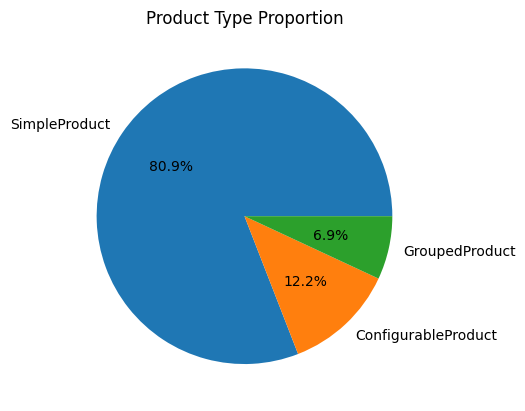

In [9]:
plt.figure()
df["product_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Product Type Proportion")
plt.show()


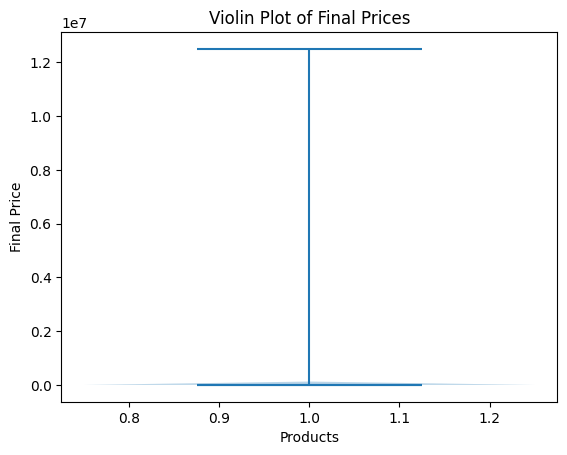

In [10]:
plt.figure()
plt.violinplot(df["pricing.finalPrice.value"].dropna(), showmeans=True)
plt.xlabel("Products")
plt.ylabel("Final Price")
plt.title("Violin Plot of Final Prices")
plt.show()


In [11]:
def split_train_test(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
    
    return X_train, X_test, y_train, y_test


In [12]:
X_train, X_test, y_train, y_test = split_train_test(X, y)

X_train: (75144, 262145), X_test: (18787, 262145)
y_train: (75144,), y_test: (18787,)


In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Ensure results folder exists
os.makedirs("results", exist_ok=True)

# Global DataFrame to store classification metrics
classification_metrics_df = pd.DataFrame(
    columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)

def calculate_metrics(algorithm, y_pred, y_test, y_score=None):
   

    # -----------------------------
    # Load target label encoder (if exists)
    # -----------------------------
    encoder_path = os.path.join("models", "product_type_encoder.pkl")
    if os.path.exists(encoder_path):
        le_target = joblib.load(encoder_path)
        categories = le_target.classes_
    else:
        categories = np.unique(y_test)

    n_classes = len(categories)

    # -----------------------------
    # Classification Metrics
    # -----------------------------
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0) * 100

    global classification_metrics_df
    classification_metrics_df.loc[len(classification_metrics_df)] = [
        algorithm, acc, prec, rec, f1
    ]

    print(f"\n{algorithm} Metrics")
    print("-" * 40)
    print(f"Accuracy : {acc:.2f}%")
    print(f"Precision: {prec:.2f}%")
    print(f"Recall   : {rec:.2f}%")
    print(f"F1-Score : {f1:.2f}%")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=range(n_classes),
            target_names=categories,
            zero_division=0
        )
    )

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=categories,
        yticklabels=categories
    )
    plt.title(f"{algorithm} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(f"results/{algorithm.replace(' ', '_')}_confusion_matrix.png")
    plt.show()

    # -----------------------------
    # ROC Curve
    # -----------------------------
    if y_score is not None:
        plt.figure(figsize=(10, 8))

        # -------- Binary classification --------
        if n_classes == 2:
            fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")

        # -------- Multiclass classification --------
        else:
            y_test_bin = label_binarize(y_test, classes=range(n_classes))

            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(
                    fpr,
                    tpr,
                    lw=2,
                    label=f"{categories[i]} (AUC = {roc_auc:.2f})"
                )

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{algorithm} - ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"results/{algorithm.replace(' ', '_')}_roc_curve.png")
        plt.show()


In [14]:
from sklearn.ensemble import GradientBoostingClassifier
import os
import joblib

def train_gradient_boosting_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    learning_rate=0.01,
    n_estimators=100,
    max_depth=3,
    subsample=1.0,
    random_state=42
):
    model_path = os.path.join(MODEL_DIR, "gradient_boosting_classifier.pkl")

    # -----------------------------
    # Load or Train
    # -----------------------------
    if os.path.exists(model_path):
        print("Loading Gradient Boosting Classifier...")
        model = joblib.load(model_path)
    else:
        print("Training Gradient Boosting Classifier...")
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            subsample=subsample,
            random_state=random_state
        )
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print(f"Model saved to {model_path}")

    # -----------------------------
    # Predictions
    # -----------------------------
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # -----------------------------
    # Evaluation
    # -----------------------------
    calculate_metrics(
        algorithm="Gradient Boosting Classifier",
        y_pred=y_pred,
        y_test=y_test,
        y_score=y_score
    )

    return model


Loading Gradient Boosting Classifier...

Gradient Boosting Classifier Metrics
----------------------------------------
Accuracy : 81.14%
Precision: 27.05%
Recall   : 33.33%
F1-Score : 29.86%

Classification Report:
                     precision    recall  f1-score   support

ConfigurableProduct       0.00      0.00      0.00      2262
     GroupedProduct       0.00      0.00      0.00      1282
      SimpleProduct       0.81      1.00      0.90     15243

           accuracy                           0.81     18787
          macro avg       0.27      0.33      0.30     18787
       weighted avg       0.66      0.81      0.73     18787



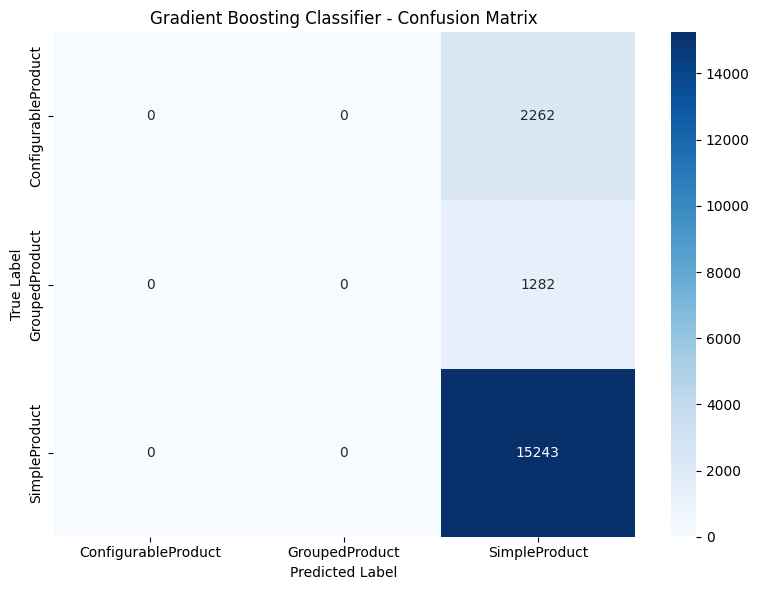

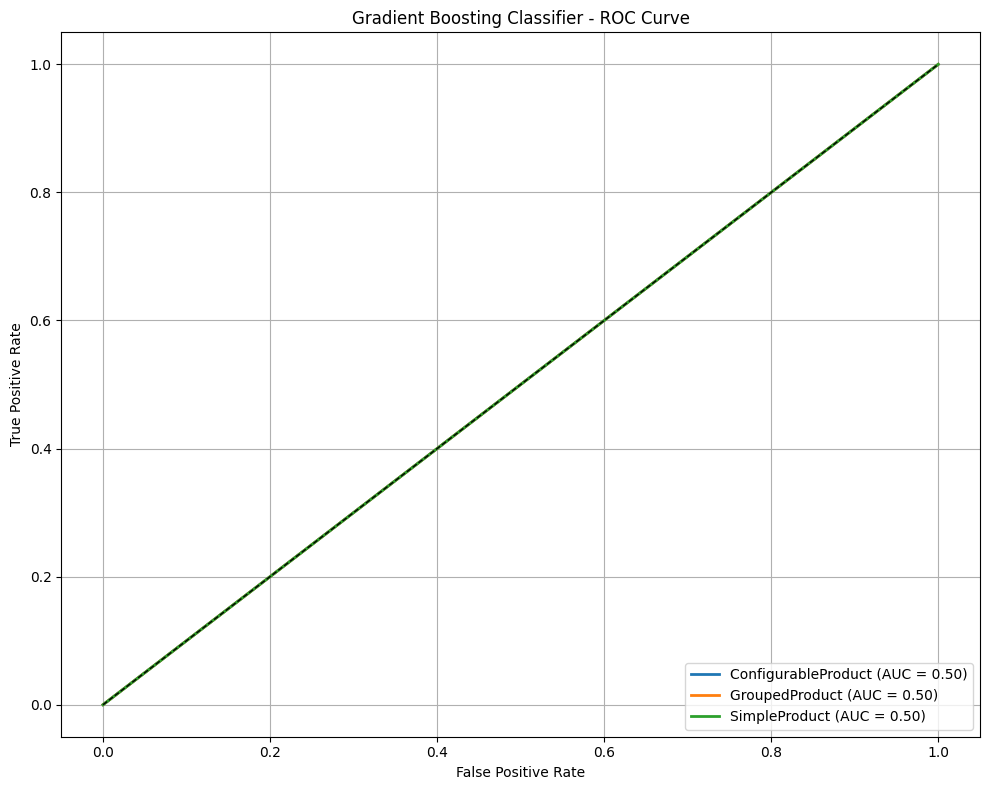

GradientBoostingClassifier(learning_rate=1e-18, n_estimators=2, random_state=42)

In [15]:
train_gradient_boosting_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    learning_rate=0.01,
    n_estimators=2,
    max_depth=3,
    subsample=1.0,
    random_state=42
)

In [16]:
from lightgbm import LGBMClassifier
import os
import joblib

def train_lgbm_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    learning_rate=0.01,
    n_estimators=2,
    max_depth=-1,
    num_leaves=31,
    subsample=1.0,
    random_state=42
):
    model_path = os.path.join(MODEL_DIR, "lgbm_classifier.pkl")

    # -----------------------------
    # Load or Train
    # -----------------------------
    if os.path.exists(model_path):
        print("Loading LGBM Classifier...")
        model = joblib.load(model_path)
    else:
        print("Training LGBM Classifier...")
        model = LGBMClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            num_leaves=num_leaves,
            subsample=subsample,
            random_state=random_state
        )
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print(f"Model saved to {model_path}")

    # -----------------------------
    # Predictions
    # -----------------------------
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # -----------------------------
    # Evaluation
    # -----------------------------
    calculate_metrics(
        algorithm="LGBM Classifier",
        y_pred=y_pred,
        y_test=y_test,
        y_score=y_score
    )

    return model


Loading LGBM Classifier...

LGBM Classifier Metrics
----------------------------------------
Accuracy : 81.14%
Precision: 27.05%
Recall   : 33.33%
F1-Score : 29.86%

Classification Report:
                     precision    recall  f1-score   support

ConfigurableProduct       0.00      0.00      0.00      2262
     GroupedProduct       0.00      0.00      0.00      1282
      SimpleProduct       0.81      1.00      0.90     15243

           accuracy                           0.81     18787
          macro avg       0.27      0.33      0.30     18787
       weighted avg       0.66      0.81      0.73     18787



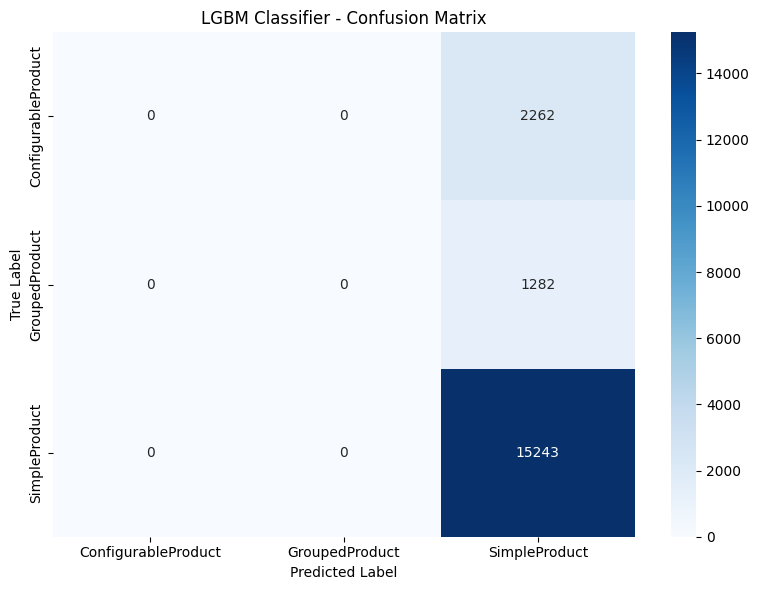

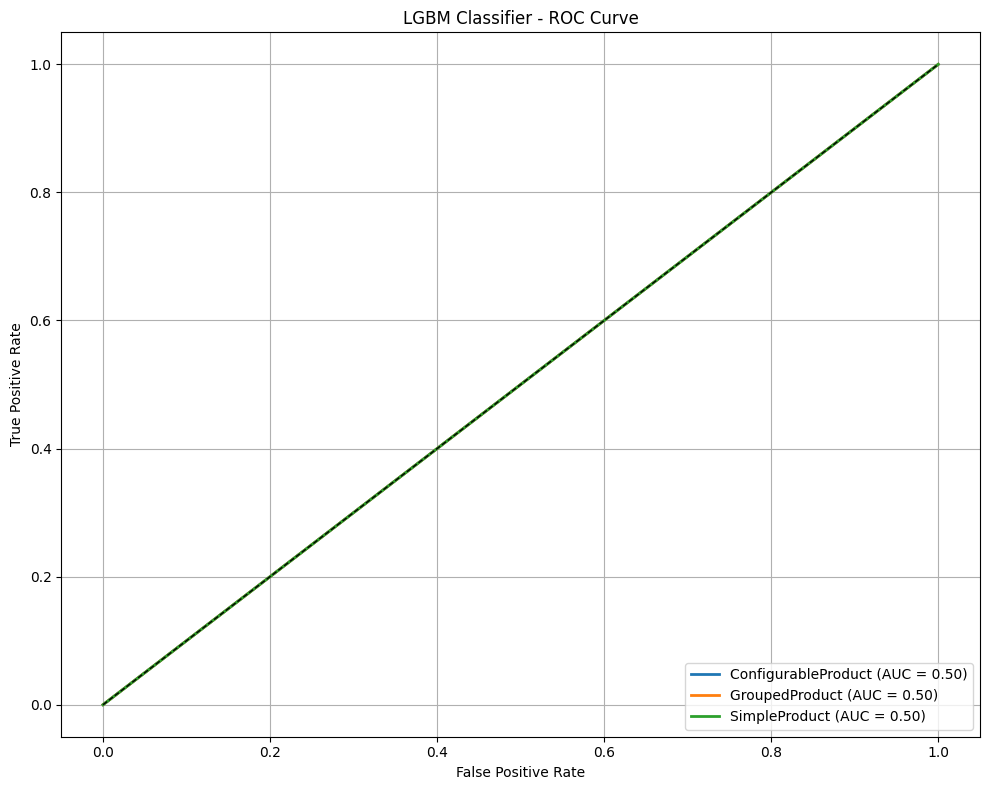

LGBMClassifier(learning_rate=1e-19, n_estimators=2, random_state=42)

In [17]:
train_lgbm_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    learning_rate=0.01,
    n_estimators=2,
    max_depth=-1,
    num_leaves=31,
    subsample=1.0,
    random_state=42
)

In [18]:
from ngboost import NGBClassifier
from ngboost.distns import k_categorical
from ngboost.scores import LogScore
import os
import joblib

def train_ngboost_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators=2,
    learning_rate=0.01,
    minibatch_frac=1.0,
    col_sample=1.0,
    random_state=42,
    distribution=None,
    score=LogScore
):
    
    model_path = os.path.join(MODEL_DIR, "ngboost_classifier.pkl")

    # -----------------------------
    # Load or Train
    # -----------------------------
    if os.path.exists(model_path):
        print("Loading NGBoost Classifier...")
        model = joblib.load(model_path)
    else:
        print("Training NGBoost Classifier...")

        # If distribution not provided, let NGBoost infer categorical from classes
        if distribution is None:
            # Use a categorical distribution with number of classes
            classes = len(set(y_train))
            distribution = k_categorical(classes)

        model = NGBClassifier(
            Dist=distribution,
            Score=score,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            minibatch_frac=minibatch_frac,
            col_sample=col_sample,
            random_state=random_state,
            verbose=False
        )

        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print(f"Model saved to {model_path}")

    # -----------------------------
    # Predictions
    # -----------------------------
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # -----------------------------
    # Evaluation
    # -----------------------------
    calculate_metrics(
        algorithm="NGBoost Classifier",
        y_pred=y_pred,
        y_test=y_test,
        y_score=y_score
    )

    return model


Loading NGBoost Classifier...

NGBoost Classifier Metrics
----------------------------------------
Accuracy : 81.14%
Precision: 27.05%
Recall   : 33.33%
F1-Score : 29.86%

Classification Report:
                     precision    recall  f1-score   support

ConfigurableProduct       0.00      0.00      0.00      2262
     GroupedProduct       0.00      0.00      0.00      1282
      SimpleProduct       0.81      1.00      0.90     15243

           accuracy                           0.81     18787
          macro avg       0.27      0.33      0.30     18787
       weighted avg       0.66      0.81      0.73     18787



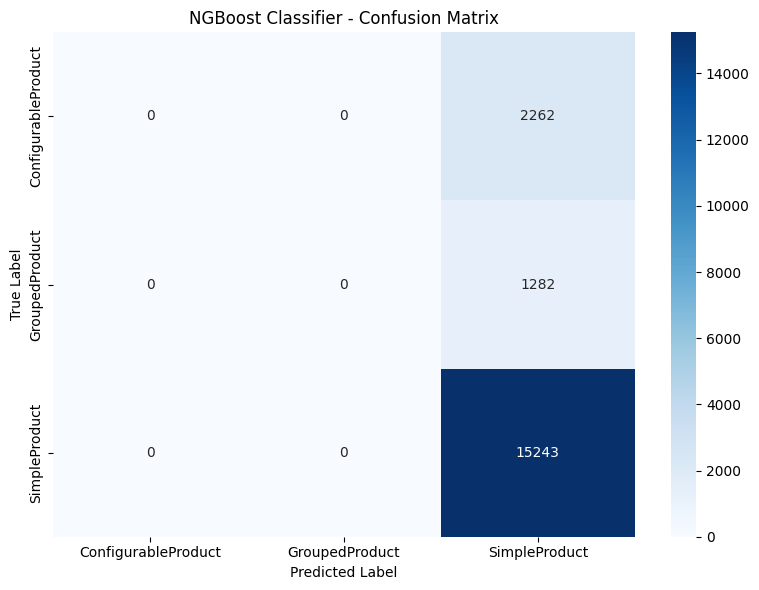

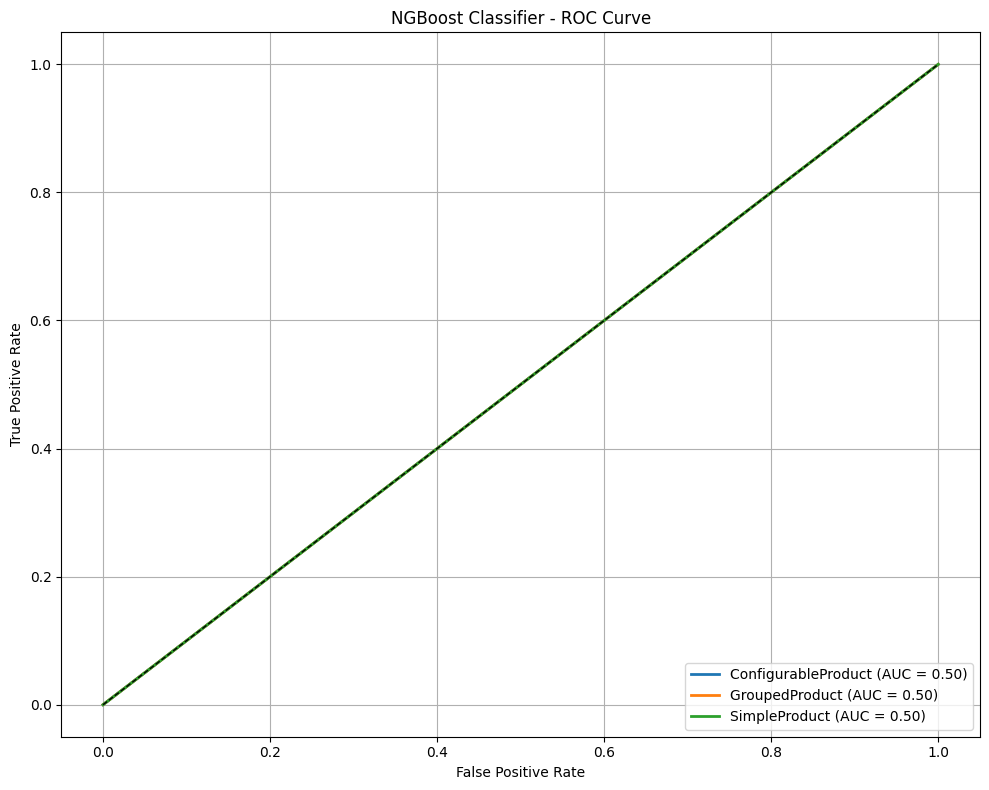

NGBClassifier(early_stopping_rounds=None, learning_rate=1e-18, n_estimators=2,
              random_state=RandomState(MT19937) at 0x1DABE0EFA40,
              validation_fraction=0.1, verbose=False)

In [19]:
train_ngboost_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators=2,
    learning_rate=0.01,
    minibatch_frac=1.0,
    col_sample=1.0,
    random_state=42,
    distribution=None,
    score=LogScore
)


In [20]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import os
import joblib

def train_calibrated_linearsvc_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    calibration_method='sigmoid',
    cv=5
):
    model_path = os.path.join(MODEL_DIR, "calibrated_linearsvc.pkl")

    # -----------------------------
    # Load or Train
    # -----------------------------
    if os.path.exists(model_path):
        print("Loading Calibrated LinearSVC Classifier...")
        model = joblib.load(model_path)
    else:
        print("Training Calibrated LinearSVC Classifier...")

        base_svc = LinearSVC(
            max_iter=5000
        )

        model = CalibratedClassifierCV(
            estimator=base_svc,
            method=calibration_method,
            cv=cv
        )

        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print(f"Model saved to {model_path}")

    # -----------------------------
    # Predictions
    # -----------------------------
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # -----------------------------
    # Evaluation
    # -----------------------------
    calculate_metrics(
        algorithm="Calibrated LinearSVC",
        y_pred=y_pred,
        y_test=y_test,
        y_score=y_score
    )

    return model


Loading Calibrated LinearSVC Classifier...

Calibrated LinearSVC Metrics
----------------------------------------
Accuracy : 99.71%
Precision: 99.49%
Recall   : 99.58%
F1-Score : 99.54%

Classification Report:
                     precision    recall  f1-score   support

ConfigurableProduct       0.99      0.99      0.99      2262
     GroupedProduct       1.00      1.00      1.00      1282
      SimpleProduct       1.00      1.00      1.00     15243

           accuracy                           1.00     18787
          macro avg       0.99      1.00      1.00     18787
       weighted avg       1.00      1.00      1.00     18787



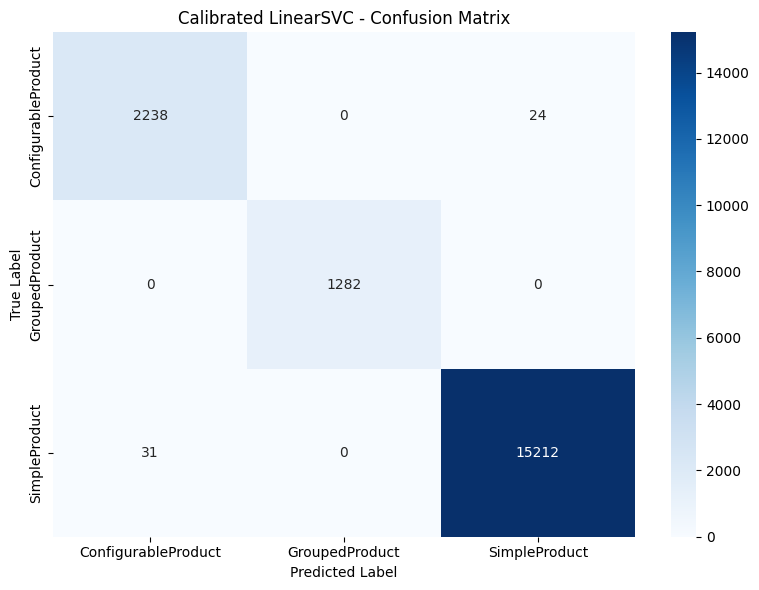

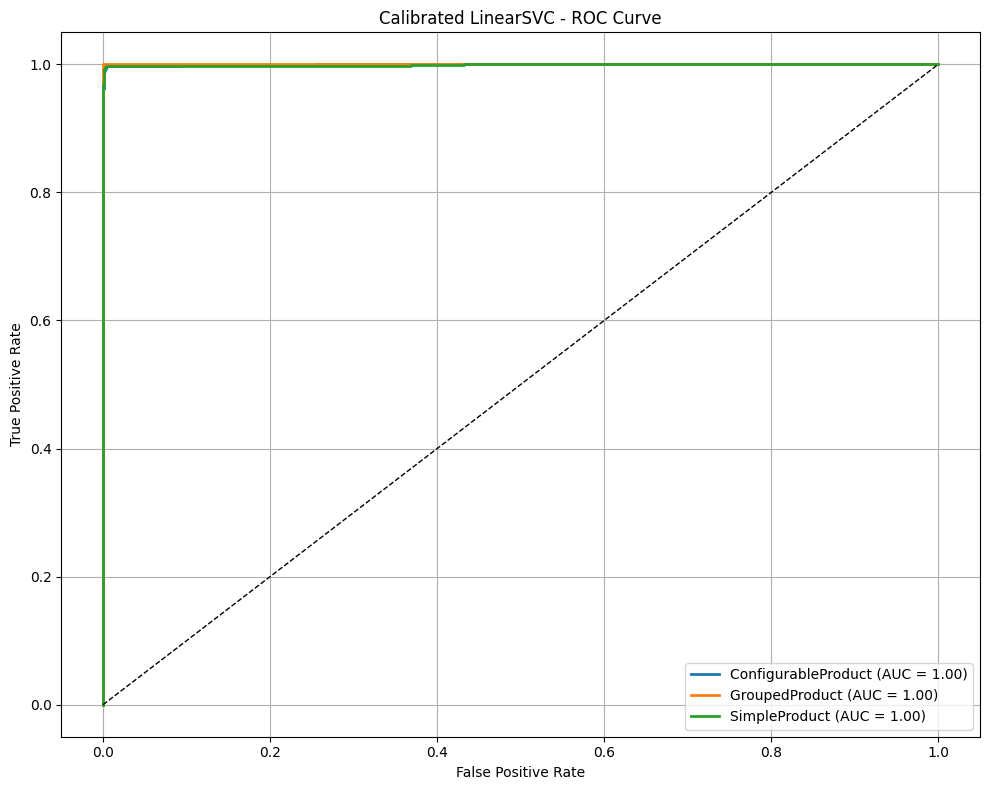

CalibratedClassifierCV(cv=5, estimator=LinearSVC(max_iter=5000))

In [21]:
train_calibrated_linearsvc_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    calibration_method='sigmoid',
    cv=5
)

In [22]:
testdata = pd.read_csv('Dataset/testdata.csv')
testdata

,name,brandName,stockStatus,description.short,description.complete,genderLabel,department,pricing.regularPrice.value,pricing.finalPrice.value,pricing.retailPrice.value
0,Citizen Drive Chronograph Men's Watch CA0595-11E,Citizen,OUT_OF_STOCK,Citizen CA0595-11E Mens,Black-tone stainless steel case with a black p...,Mens,Watches,247.99,147.50,295.00
1,Breitling Navitimer Montbrillant Bracelet Stai...,Breitling,OUT_OF_STOCK,Breitling 378A Mens,Breitling 20-18mm Navitimer Montbrillant Brace...,Mens,Watches,1371.99,995.00,1580.00
2,Moncler Grenoble Black Ski Trousers,Moncler,IN_STOCK,Moncler H20982A00006-5961K-999 Ladies,Moncler Ladies Bottoms. Fashion category: Pant...,Womens,Clothing,928.99,478.00,1210.00
3,Baume et Mercier Promesse Core Mother of Pearl...,Baume Et Mercier,OUT_OF_STOCK,Baume et Mercier M0A10288 Ladies,Stainless steel case with a blue (calfskin) le...,Womens,Watches,2048.99,950.00,2700.00
4,Akribos XXIV Womens Casual Quartz Blue Dial Me...,Akribos Xxiv,IN_STOCK,Akribos XXIV P50183 Mens,Silver Ion Plated Alloy Case on Stainless Stee...,Mens,Watches,282.99,51.00,395.00
5,Swiss Arabian Ladies Wild Spirit EDP Spray 3.4...,Swiss Arabian,IN_STOCK,Swiss Arabian 6295124030086 Ladies,<p>Unleash your inner confidence with Swiss Ar...,Womens,Fragrances,34.99,34.99,34.99
6,Rag and Bone Demo Cat Eye Ladies Eyeglasses RN...,Rag And Bone,IN_STOCK,Rag and Bone RNB3042/G 0RHL 53 Ladies,Rag and Bone Eyeglasses. Series number: RNB304...,Womens,Eyeglasses,155.99,34.99,223.00
7,Rolex Lady-Datejust Champagne Diamond Dial 18k...,Rolex,IN_STOCK,Rolex M279138RBR-0006 Ladies,18kt yellow gold case with a 18kt yellow gold ...,Womens,Watches,37783.99,31835.00,41000.00
8,Citizen Quartz Mother of Pearl Dial Ladies Wat...,Citizen,OUT_OF_STOCK,Citizen EU6030-81D Ladies,Silver-tone stainless steel case with a silver...,Womens,Watches,82.99,66.89,109.99
9,David Beckham Grey Sport Men's Sunglasses DB 1...,David Beckham,IN_STOCK,David Beckham DB 1034/S 0807/M9 53 Mens,David Beckham Sunglasses. Series number: DB 10...,Mens,Sunglasses,167.99,59.99,240.00


In [23]:
# Preprocess test data
X_test_new, y_test_new = preprocess_data(testdata, is_train=False)




In [24]:
target_le_path = os.path.join(MODEL_DIR, "product_type_encoder.pkl")
target_le = joblib.load(target_le_path)
# Load trained model 
calibrated_linearsvc_model_path = os.path.join(MODEL_DIR, "calibrated_linearsvc.pkl")
calibrated_linearsvc_model = joblib.load(calibrated_linearsvc_model_path)

# Predict
pred = calibrated_linearsvc_model.predict(X_test_new)

pred_original = target_le.inverse_transform(pred)


In [25]:
testdata['predictions'] = pred_original

testdata

,name,brandName,stockStatus,description.short,description.complete,genderLabel,department,pricing.regularPrice.value,pricing.finalPrice.value,pricing.retailPrice.value,predictions
0,Citizen Drive Chronograph Men's Watch CA0595-11E,Citizen,OUT_OF_STOCK,Citizen CA0595-11E Mens,Black-tone stainless steel case with a black p...,Mens,Watches,247.99,147.50,295.00,SimpleProduct
1,Breitling Navitimer Montbrillant Bracelet Stai...,Breitling,OUT_OF_STOCK,Breitling 378A Mens,Breitling 20-18mm Navitimer Montbrillant Brace...,Mens,Watches,1371.99,995.00,1580.00,SimpleProduct
2,Moncler Grenoble Black Ski Trousers,Moncler,IN_STOCK,Moncler H20982A00006-5961K-999 Ladies,Moncler Ladies Bottoms. Fashion category: Pant...,Womens,Clothing,928.99,478.00,1210.00,ConfigurableProduct
3,Baume et Mercier Promesse Core Mother of Pearl...,Baume Et Mercier,OUT_OF_STOCK,Baume et Mercier M0A10288 Ladies,Stainless steel case with a blue (calfskin) le...,Womens,Watches,2048.99,950.00,2700.00,SimpleProduct
4,Akribos XXIV Womens Casual Quartz Blue Dial Me...,Akribos Xxiv,IN_STOCK,Akribos XXIV P50183 Mens,Silver Ion Plated Alloy Case on Stainless Stee...,Mens,Watches,282.99,51.00,395.00,SimpleProduct
5,Swiss Arabian Ladies Wild Spirit EDP Spray 3.4...,Swiss Arabian,IN_STOCK,Swiss Arabian 6295124030086 Ladies,<p>Unleash your inner confidence with Swiss Ar...,Womens,Fragrances,34.99,34.99,34.99,SimpleProduct
6,Rag and Bone Demo Cat Eye Ladies Eyeglasses RN...,Rag And Bone,IN_STOCK,Rag and Bone RNB3042/G 0RHL 53 Ladies,Rag and Bone Eyeglasses. Series number: RNB304...,Womens,Eyeglasses,155.99,34.99,223.00,SimpleProduct
7,Rolex Lady-Datejust Champagne Diamond Dial 18k...,Rolex,IN_STOCK,Rolex M279138RBR-0006 Ladies,18kt yellow gold case with a 18kt yellow gold ...,Womens,Watches,37783.99,31835.00,41000.00,SimpleProduct
8,Citizen Quartz Mother of Pearl Dial Ladies Wat...,Citizen,OUT_OF_STOCK,Citizen EU6030-81D Ladies,Silver-tone stainless steel case with a silver...,Womens,Watches,82.99,66.89,109.99,SimpleProduct
9,David Beckham Grey Sport Men's Sunglasses DB 1...,David Beckham,IN_STOCK,David Beckham DB 1034/S 0807/M9 53 Mens,David Beckham Sunglasses. Series number: DB 10...,Mens,Sunglasses,167.99,59.99,240.00,SimpleProduct
